In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Tesla indexed CSV
df_tsla = pd.read_csv("../data/processed/tsla_cleaned.csv", parse_dates=["Date"], index_col="Date")

# Use Close price only
df_tsla["Close"] = pd.to_numeric(df_tsla["Close"], errors="coerce")
df_tsla = df_tsla.dropna(subset=["Close"])
tsla_series = df_tsla["Close"].astype(float)



# Chronological train/test split
train = tsla_series[: "2024-12-31"]   # 2015–2024
test  = tsla_series["2025-01-01":]    # 2025–2026

print("Train length:", len(train))
print("Test length:", len(test))


Train length: 2516
Test length: 259


In [6]:
import warnings
warnings.filterwarnings("ignore")

from pmdarima import auto_arima

auto_model = auto_arima(
    train,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=False,     # If you suspect seasonality you can set seasonal=True and specify m
    trace=True,
    error_action="ignore",
    stepwise=True
)

print("Selected ARIMA order:", auto_model.order)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.61 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.15 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.31 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.460 seconds
Selected ARIMA order: (0, 1, 0)


In [7]:
n_periods = len(test)
arima_forecast = auto_model.predict(n_periods=n_periods)
arima_pred = pd.Series(arima_forecast, index=test.index)


c:\Users\azeb.mehrete\Documents\KAIM\KAIM-9\w9env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [8]:
from sklearn.preprocessing import MinMaxScaler

# Scale series
scaler = MinMaxScaler()
scaled_series = scaler.fit_transform(tsla_series.values.reshape(-1,1))

# Window for LSTM
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled_series)


In [9]:
# Indices considering window
window = 60
train_size = len(train) - window

X_train = X_all[:train_size]
y_train = y_all[:train_size]

X_test = X_all[train_size:]
y_test = y_all[train_size:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(50),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mean_squared_error")

# Train
history = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - loss: 0.0090 - val_loss: 0.0027
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 8.7864e-04 - val_loss: 0.0034
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 7.2468e-04 - val_loss: 0.0021
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 8.3034e-04 - val_loss: 0.0027
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 6.0887e-04 - val_loss: 0.0020
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 5.7666e-04 - val_loss: 0.0016
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 5.1894e-04 - val_loss: 0.0015
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 4.9198e-04 - val_loss: 0.0016
Epoch 9/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 4.4931e-04 - val_loss: 0.0015
Epoch 10/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 4.1483e-04 - val_loss: 0.0022
Epoch 11/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 4.3856e-04 - val_loss: 0.0012
Epoch 12/30
70/70 ━━━━━

In [11]:
lstm_scaled_preds = lstm_model.predict(X_test)
lstm_preds = scaler.inverse_transform(lstm_scaled_preds).flatten()

# Align predictions with test index
lstm_index = test.index[window:]


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def safe_metrics(true, pred):
    """
    Compute MAE, RMSE, and MAPE safely by aligning arrays
    and removing any NaNs.
    """
    # Convert to numpy
    true_arr, pred_arr = np.array(true), np.array(pred)

    # Shorten to the same minimum length
    min_len = min(len(true_arr), len(pred_arr))
    true_arr, pred_arr = true_arr[:min_len], pred_arr[:min_len]

    # Mask valid (non-NaN) values
    mask = (~np.isnan(true_arr)) & (~np.isnan(pred_arr))
    true_arr, pred_arr = true_arr[mask], pred_arr[mask]

    if len(true_arr) == 0:
        return np.nan, np.nan, np.nan

    mae  = mean_absolute_error(true_arr, pred_arr)
    rmse = np.sqrt(mean_squared_error(true_arr, pred_arr))
    mape = np.mean(np.abs((true_arr - pred_arr) / np.where(true_arr == 0, 1e-8, true_arr))) * 100
    return mae, rmse, mape

# ----------------------------------------

# Ensure ARIMA forecast aligns with actual test data
arima_pred_aligned = arima_pred.values[: len(test.values)]
arima_true_aligned = test.values[: len(arima_pred_aligned)]

arima_mae, arima_rmse, arima_mape = safe_metrics(arima_true_aligned, arima_pred_aligned)

# For LSTM: match the end portion of test to lengths of predictions
lstm_true = test.values[-len(lstm_preds):]
lstm_pred_vals = lstm_preds[:len(lstm_true)]

lstm_mae, lstm_rmse, lstm_mape = safe_metrics(lstm_true, lstm_pred_vals)

# Compile results
results = pd.DataFrame({
    "Model": ["ARIMA", "LSTM"],
    "MAE": [arima_mae, lstm_mae],
    "RMSE": [arima_rmse, lstm_rmse],
    "MAPE (%)": [arima_mape, lstm_mape]
})

print(results)


   Model        MAE       RMSE  MAPE (%)
0  ARIMA        NaN        NaN       NaN
1   LSTM  11.893335  15.208182  3.435754


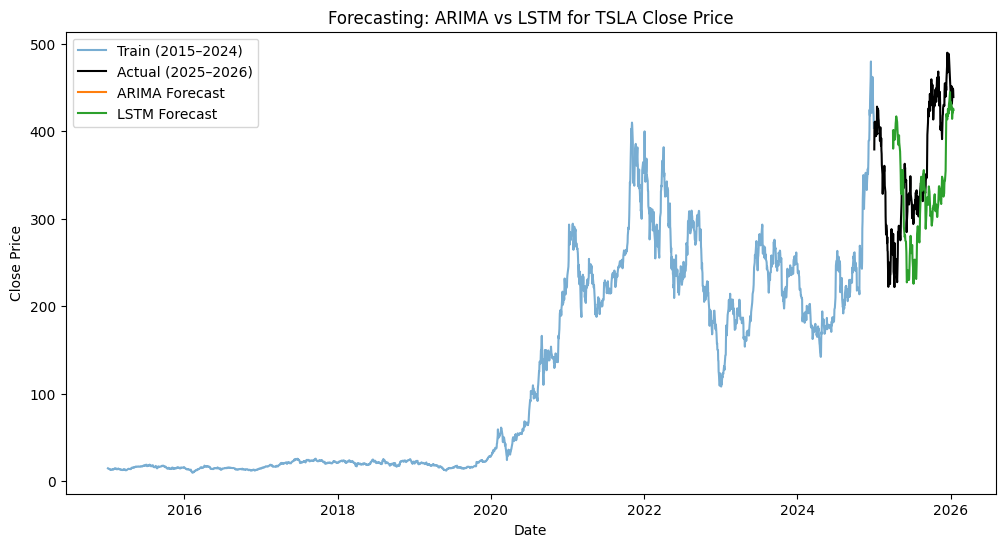

In [20]:
# Align lengths explicitly
min_len = min(len(lstm_preds), len(test.index[window:]))
lstm_index = test.index[window:window+min_len]
lstm_preds = lstm_preds[:min_len]  # truncate predictions
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train (2015–2024)", alpha=0.6)
plt.plot(test.index, test, label="Actual (2025–2026)", color="black")
plt.plot(arima_pred.index, arima_pred.values, label="ARIMA Forecast")
plt.plot(lstm_index, lstm_preds, label="LSTM Forecast")
plt.legend()
plt.title("Forecasting: ARIMA vs LSTM for TSLA Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()
